# Waste Generation Analysis Using Machine Learning

**Case Study No. 73 — B.Tech CSE Machine Learning Final Examination Project**

This project investigates factors associated with changes in municipal solid waste (MSW) generation. Using the World Bank *What A Waste* global dataset, we apply regression, classification, and clustering models to understand what drives waste generation and to predict waste volumes for municipalities.

**Models used (Case Study 73 requirement):**
1. Linear Regression
2. K-Nearest Neighbors (KNN)
3. Decision Tree
4. Random Forest
5. Logistic Regression
6. Naive Bayes
7. Hierarchical Clustering

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    ConfusionMatrixDisplay
)

from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import AgglomerativeClustering

print("All libraries imported successfully.")

All libraries imported successfully.


## 2. Load Dataset

In [2]:
df = pd.read_csv("data/country_level_data_0.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (217, 51)


In [3]:
# Select only the columns that are useful for this project
# and rename them to short, readable names.

cols_needed = {
    "country_name"                                    : "country",
    "region_id"                                       : "region",
    "income_id"                                       : "income",
    "gdp"                                             : "gdp",
    "population_population_number_of_people"          : "population",
    "total_msw_total_msw_generated_tons_year"         : "waste_tons",
    "composition_food_organic_waste_percent"          : "organic_pct",
    "composition_glass_percent"                       : "glass_pct",
    "composition_metal_percent"                       : "metal_pct",
    "composition_other_percent"                       : "other_pct",
    "composition_paper_cardboard_percent"             : "paper_pct",
    "composition_plastic_percent"                     : "plastic_pct",
}

df = df[list(cols_needed.keys())].rename(columns=cols_needed)

print("Columns selected and renamed.")
print(df.head())

Columns selected and renamed.
       country region income           gdp  population    waste_tons  \
0        Aruba    LCN    HIC           NaN    103187.0  8.813202e+04   
1  Afghanistan    SAS    LIC  2.141361e+10  34656032.0  5.628525e+06   
2       Angola    SSF    LMC  1.030423e+11  25096150.0  4.213644e+06   
3      Albania    ECS    UMC  1.347108e+10   2880703.0  1.142964e+06   
4      Andorra    ECS    HIC  3.319880e+09     82431.0  4.300000e+04   

   organic_pct  glass_pct  metal_pct  other_pct  paper_pct  plastic_pct  
0          NaN        NaN        NaN        NaN        NaN          NaN  
1          NaN        NaN        NaN        NaN        NaN          NaN  
2         51.8        6.7        4.4      11.50       11.9         13.5  
3         51.4        4.5        4.8      15.21        9.9          9.6  
4         31.2        8.2        2.6      11.60       35.1         11.3  


## 3. Data Understanding

In [4]:
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

Dataset shape: (217, 12)

Column names:
['country', 'region', 'income', 'gdp', 'population', 'waste_tons', 'organic_pct', 'glass_pct', 'metal_pct', 'other_pct', 'paper_pct', 'plastic_pct']


In [5]:
print("Data types and non-null counts:")
df.info()

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   country      216 non-null    object 
 1   region       217 non-null    object 
 2   income       217 non-null    object 
 3   gdp          192 non-null    float64
 4   population   217 non-null    float64
 5   waste_tons   215 non-null    float64
 6   organic_pct  176 non-null    float64
 7   glass_pct    171 non-null    float64
 8   metal_pct    170 non-null    float64
 9   other_pct    175 non-null    float64
 10  paper_pct    176 non-null    float64
 11  plastic_pct  175 non-null    float64
dtypes: float64(9), object(3)
memory usage: 20.5+ KB


In [6]:
print("Statistical summary:")
display(df.describe())

Statistical summary:


,gdp,population,waste_tons,organic_pct,glass_pct,metal_pct,other_pct,paper_pct,plastic_pct
count,1.920000e+02,2.170000e+02,2.150000e+02,176.000000,171.000000,170.000000,175.000000,176.000000,175.000000
mean,3.980093e+11,3.211832e+07,8.582534e+06,41.734392,4.756173,4.276838,18.418010,15.277361,11.687394
std,1.534521e+12,1.232717e+08,2.714256e+07,17.898231,3.399614,3.522976,16.015182,9.478098,5.585085
min,3.921616e+07,1.109700e+04,3.989486e+03,3.100000,0.000000,0.100000,0.800000,2.000000,1.000000
25%,7.772412e+09,7.462210e+05,2.138795e+05,29.225000,2.805000,2.000000,9.000000,8.625000,7.950000
50%,2.817728e+10,5.683483e+06,1.768977e+06,43.200000,4.000000,3.000000,14.000000,13.155000,11.500000
75%,1.970804e+11,2.120300e+07,4.865910e+06,54.550000,5.900000,5.000000,22.351351,20.000000,14.555000
max,1.692033e+13,1.371220e+09,2.580000e+08,87.600000,21.400000,19.380000,92.700000,58.700000,32.000000


In [7]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
country         1
region          0
income          0
gdp            25
population      0
waste_tons      2
organic_pct    41
glass_pct      46
metal_pct      47
other_pct      42
paper_pct      41
plastic_pct    42
dtype: int64

Duplicate rows: 0


In [8]:
print("Target variable — waste_tons:")
print(df["waste_tons"].describe())

Target variable — waste_tons:
count    2.150000e+02
mean     8.582534e+06
std      2.714256e+07
min      3.989486e+03
25%      2.138795e+05
50%      1.768977e+06
75%      4.865910e+06
max      2.580000e+08
Name: waste_tons, dtype: float64


### What we found

- **217 rows** (countries) and **12 selected columns**.
- The **target variable** is `waste_tons` — annual municipal solid waste in metric tons.
- **`waste_tons`** has only **2 missing values**, which will be dropped.
- Composition columns (`organic_pct`, `paper_pct`, etc.) have 19–21% missing values and will be filled with the column median.
- `gdp` has about 11.5% missing values — also filled with median.
- **No duplicate rows** were found.
- `region` and `income` are categorical columns that will be one-hot encoded.
- The target ranges from ~4,000 to ~258 million tons, showing it is highly right-skewed.

## 4. Data Cleaning & Preprocessing

In [9]:
# Step 1 — Drop the 2 rows where the target is missing.
# We cannot train or evaluate on rows without a target value.

before = len(df)
df = df.dropna(subset=["waste_tons"]).reset_index(drop=True)
after = len(df)

print("Rows before:", before)
print("Rows after :", after)
print("Rows removed:", before - after)

Rows before: 217
Rows after : 215
Rows removed: 2


In [10]:
# Step 2 — Create a classification target: Low / Medium / High waste tier.
# We use data-driven tertiles (33rd and 67th percentiles) so the three
# classes are equally balanced regardless of the data distribution.

df["waste_tier"], cutoffs = pd.qcut(
    df["waste_tons"], q=3,
    labels=["Low", "Medium", "High"],
    retbins=True
)

print("Waste tier cutoffs (tons/year):")
print(f"  Low    : up to       {cutoffs[1]:>15,.0f}")
print(f"  Medium : {cutoffs[1]:>15,.0f}  to {cutoffs[2]:>15,.0f}")
print(f"  High   : above       {cutoffs[2]:>15,.0f}")

print("\nTier counts:")
print(df["waste_tier"].value_counts())

Waste tier cutoffs (tons/year):
  Low    : up to               508,333
  Medium :         508,333  to       3,749,839
  High   : above             3,749,839

Tier counts:
waste_tier
Low       72
High      72
Medium    71
Name: count, dtype: int64


In [11]:
# Step 3 — Separate features and targets.

num_features = ["gdp", "population", "organic_pct", "glass_pct",
                "metal_pct", "other_pct", "paper_pct", "plastic_pct"]
cat_features = ["income", "region"]

X_raw = df[num_features + cat_features]
y_reg = df["waste_tons"]          # continuous target  (Regression)
y_clf = df["waste_tier"]          # 3-class target     (Classification)

print("Feature matrix shape:", X_raw.shape)
print("Regression target — first 5 values:")
print(y_reg.head().values)
print("Classification target — value counts:")
print(y_clf.value_counts())

Feature matrix shape: (215, 10)
Regression target — first 5 values:
[  88132.0167 5628525.37   4213643.585  1142964.       43000.    ]
Classification target — value counts:
waste_tier
Low       72
High      72
Medium    71
Name: count, dtype: int64


In [12]:
# Step 4 — Train / Test split (80 % / 20 %).
# stratify=y_clf keeps the Low / Medium / High proportions
# the same in both sets.

X_train_raw, X_test_raw, y_reg_train, y_reg_test, y_clf_train, y_clf_test = train_test_split(
    X_raw, y_reg, y_clf,
    test_size=0.20, random_state=42, stratify=y_clf
)

print("Training samples :", len(X_train_raw))
print("Testing  samples :", len(X_test_raw))

Training samples : 172
Testing  samples : 43


In [13]:
# Step 5 — Preprocess numeric features.
# a) Fill missing values with the column median (fit on train only).
# b) Standardise so all features have mean=0, std=1.
#    This is required for KNN and Logistic Regression.

imputer = SimpleImputer(strategy="median")
scaler  = StandardScaler()

X_train_num = scaler.fit_transform(imputer.fit_transform(X_train_raw[num_features]))
X_test_num  = scaler.transform(imputer.transform(X_test_raw[num_features]))

print("Numeric features preprocessed.")

Numeric features preprocessed.


In [14]:
# Step 6 — One-Hot Encode categorical features (income, region).
# Each unique category becomes a new 0/1 column.
# handle_unknown="ignore" silently ignores unseen categories at test time.

encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_train_cat = encoder.fit_transform(X_train_raw[cat_features])
X_test_cat  = encoder.transform(X_test_raw[cat_features])

print("Categorical features encoded.")
print("Encoded category names:", encoder.get_feature_names_out(cat_features).tolist())

Categorical features encoded.
Encoded category names: ['income_HIC', 'income_LIC', 'income_LMC', 'income_UMC', 'region_EAS', 'region_ECS', 'region_LCN', 'region_MEA', 'region_NAC', 'region_SAS', 'region_SSF']


In [15]:
# Step 7 — Combine numeric and encoded categorical columns.

X_train = np.hstack([X_train_num, X_train_cat])
X_test  = np.hstack([X_test_num,  X_test_cat])

all_feature_names = num_features + encoder.get_feature_names_out(cat_features).tolist()

print("Final feature matrix shape — Train:", X_train.shape)
print("Final feature matrix shape — Test :", X_test.shape)

Final feature matrix shape — Train: (172, 19)
Final feature matrix shape — Test : (43, 19)


**Preprocessing summary:**
- Dropped 2 rows with missing target.
- Created `waste_tier` (Low / Medium / High) from data-driven tertiles.
- 80 / 20 train-test split with stratification.
- Numeric features: median imputation → StandardScaler.
- Categorical features: OneHotEncoding (income, region).
- All preprocessing fitted on **training data only** to prevent data leakage.

## 5. Exploratory Data Analysis

### Graph 1 — Waste Generation Distribution

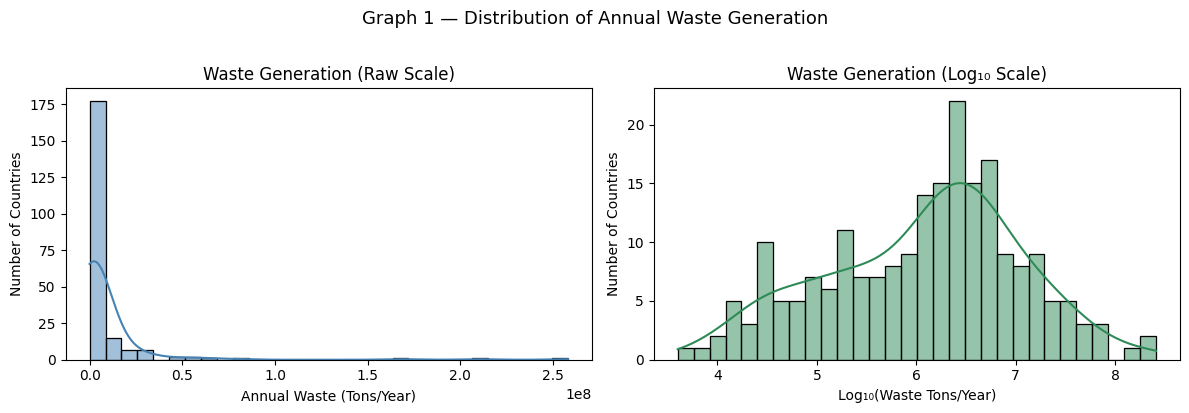

Insight: The raw distribution is strongly right-skewed.
A few high-population countries generate far more waste than the majority.
The log scale shows a more normal bell-shaped distribution.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df["waste_tons"].dropna(), bins=30, kde=True, color="steelblue", ax=axes[0])
axes[0].set_title("Waste Generation (Raw Scale)")
axes[0].set_xlabel("Annual Waste (Tons/Year)")
axes[0].set_ylabel("Number of Countries")

sns.histplot(np.log10(df["waste_tons"].dropna()), bins=30, kde=True, color="seagreen", ax=axes[1])
axes[1].set_title("Waste Generation (Log₁₀ Scale)")
axes[1].set_xlabel("Log₁₀(Waste Tons/Year)")
axes[1].set_ylabel("Number of Countries")

plt.suptitle("Graph 1 — Distribution of Annual Waste Generation", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Insight: The raw distribution is strongly right-skewed.")
print("A few high-population countries generate far more waste than the majority.")
print("The log scale shows a more normal bell-shaped distribution.")

### Graph 2 — Population vs Waste Generation

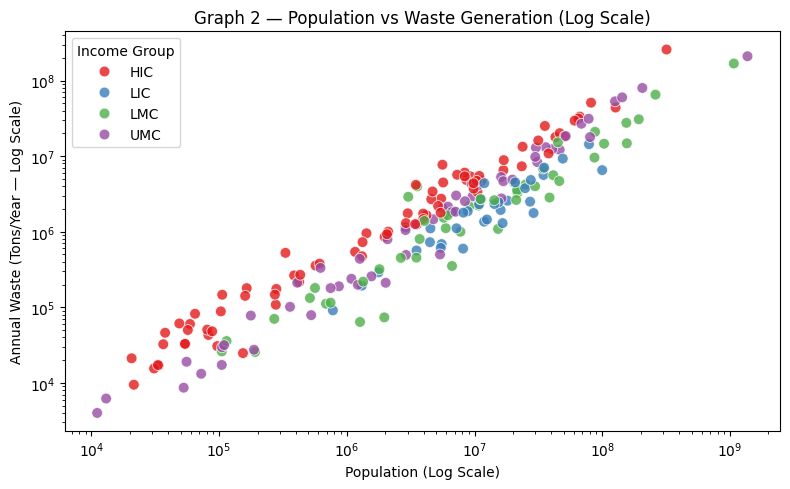

Insight: Countries with larger populations generate significantly more waste.
High-income countries (HIC) consistently appear in the upper-right of the plot.


In [17]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="population", y="waste_tons",
    hue="income", palette="Set1", s=60, alpha=0.8
)
plt.xscale("log")
plt.yscale("log")
plt.title("Graph 2 — Population vs Waste Generation (Log Scale)")
plt.xlabel("Population (Log Scale)")
plt.ylabel("Annual Waste (Tons/Year — Log Scale)")
plt.legend(title="Income Group")
plt.tight_layout()
plt.show()

print("Insight: Countries with larger populations generate significantly more waste.")
print("High-income countries (HIC) consistently appear in the upper-right of the plot.")

### Graph 3 — GDP vs Waste Generation

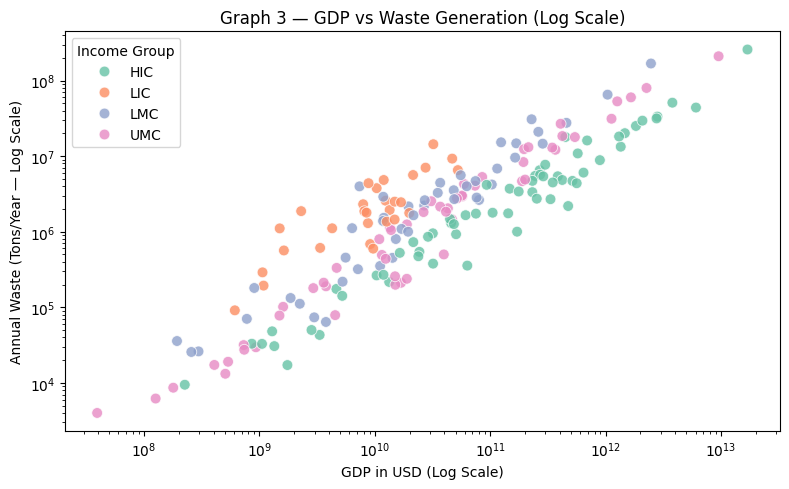

Insight: GDP has a strong positive relationship with waste generation.
Wealthier economies produce more total municipal solid waste.


In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="gdp", y="waste_tons",
    hue="income", palette="Set2", s=60, alpha=0.8
)
plt.xscale("log")
plt.yscale("log")
plt.title("Graph 3 — GDP vs Waste Generation (Log Scale)")
plt.xlabel("GDP in USD (Log Scale)")
plt.ylabel("Annual Waste (Tons/Year — Log Scale)")
plt.legend(title="Income Group")
plt.tight_layout()
plt.show()

print("Insight: GDP has a strong positive relationship with waste generation.")
print("Wealthier economies produce more total municipal solid waste.")

### Graph 4 — Waste Composition by Income Group

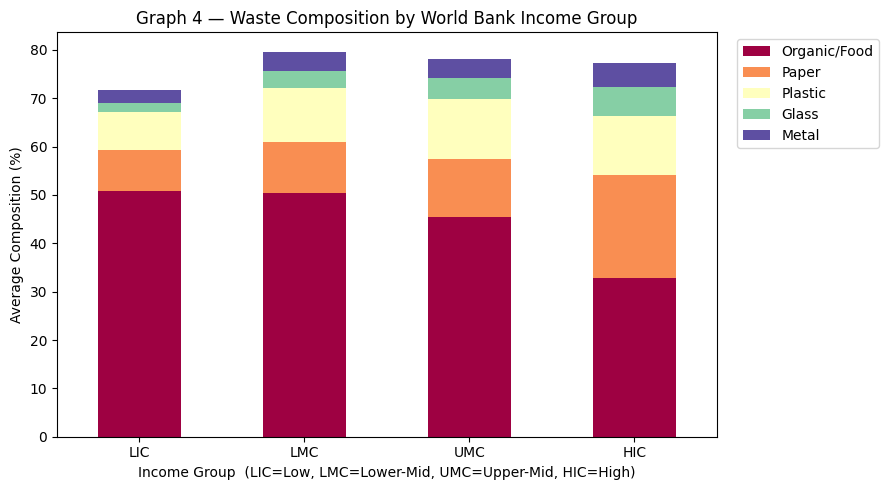

Insight: Low-income countries have over 60% organic/food waste.
High-income countries generate higher shares of paper, plastic, and glass — dry recyclables.


In [19]:
comp_cols = ["organic_pct", "paper_pct", "plastic_pct", "glass_pct", "metal_pct"]
income_order = ["LIC", "LMC", "UMC", "HIC"]

comp_means = (
    df.groupby("income")[comp_cols]
    .mean()
    .loc[income_order]
)
comp_means.columns = ["Organic/Food", "Paper", "Plastic", "Glass", "Metal"]

comp_means.plot(kind="bar", stacked=True, colormap="Spectral", figsize=(9, 5))
plt.title("Graph 4 — Waste Composition by World Bank Income Group")
plt.xlabel("Income Group  (LIC=Low, LMC=Lower-Mid, UMC=Upper-Mid, HIC=High)")
plt.ylabel("Average Composition (%)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Insight: Low-income countries have over 60% organic/food waste.")
print("High-income countries generate higher shares of paper, plastic, and glass — dry recyclables.")

### Graph 5 — Waste Generation by Waste Tier

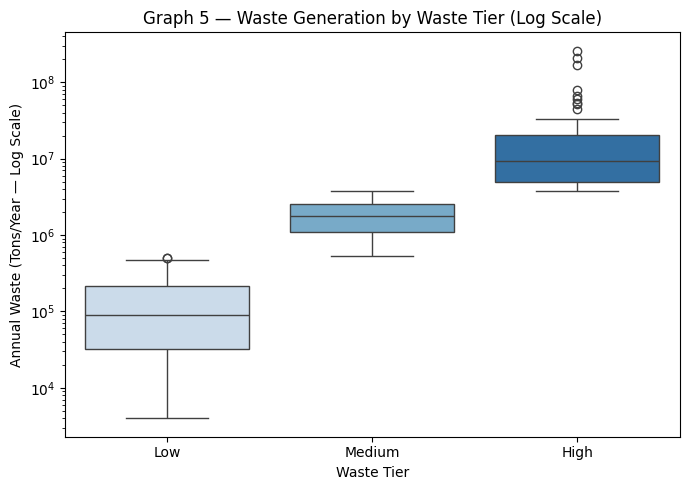

Insight: The three tiers are clearly separated.
The Low tier has compact distributions; the High tier has large spread due to megacities.


In [20]:
plt.figure(figsize=(7, 5))
order = ["Low", "Medium", "High"]
sns.boxplot(data=df, x="waste_tier", y="waste_tons", order=order, palette="Blues")
plt.yscale("log")
plt.title("Graph 5 — Waste Generation by Waste Tier (Log Scale)")
plt.xlabel("Waste Tier")
plt.ylabel("Annual Waste (Tons/Year — Log Scale)")
plt.tight_layout()
plt.show()

print("Insight: The three tiers are clearly separated.")
print("The Low tier has compact distributions; the High tier has large spread due to megacities.")

### Graph 6 — Correlation Heatmap

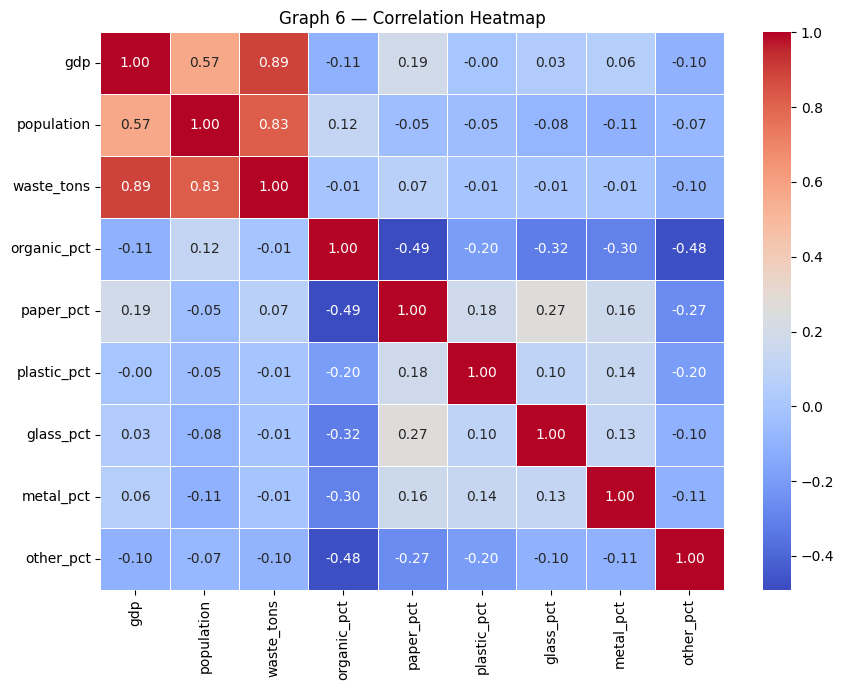

Correlation with waste_tons:
waste_tons     1.000000
gdp            0.891905
population     0.825136
paper_pct      0.071969
plastic_pct   -0.007976
organic_pct   -0.009273
metal_pct     -0.012161
glass_pct     -0.012284
other_pct     -0.098516
Name: waste_tons, dtype: float64


In [21]:
numeric_cols = ["gdp", "population", "waste_tons",
                "organic_pct", "paper_pct", "plastic_pct",
                "glass_pct", "metal_pct", "other_pct"]

plt.figure(figsize=(9, 7))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Graph 6 — Correlation Heatmap")
plt.tight_layout()
plt.show()

print("Correlation with waste_tons:")
print(corr["waste_tons"].sort_values(ascending=False))

### What we found from EDA

- **Population** and **GDP** are the two strongest predictors of waste generation.
- Low-income countries are dominated by **organic waste**, while richer countries produce more **recyclables**.
- The target variable is heavily skewed — most countries generate moderate waste,   but a handful of large economies generate far more.
- **Composition features** (organic, paper, plastic) are moderately useful but have   higher missingness.

## 6. Train-Test Split

The dataset was split **80 % training / 20 % testing** with `random_state=42` during pre-processing (Section 4).  
`stratify=y_clf` ensures the Low / Medium / High proportions are equal in both sets.

## 7. Linear Regression

**Simple idea:**  
Linear Regression fits a straight-line (or hyperplane) relationship between the input features and waste generation. It is the simplest regression benchmark.

In [22]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_reg_train)
lr_pred = lr_model.predict(X_test)

print("Linear Regression trained and predictions generated.")

Linear Regression trained and predictions generated.


In [23]:
lr_mae  = mean_absolute_error(y_reg_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_reg_test, lr_pred))
lr_r2   = r2_score(y_reg_test, lr_pred)

print(f"MAE  : {lr_mae:>15,.0f} tons")
print(f"RMSE : {lr_rmse:>15,.0f} tons")
print(f"R²   : {lr_r2:.4f}")

MAE  :       2,616,082 tons
RMSE :       5,695,911 tons
R²   : 0.7158


**Interpretation:**  
- **R²** tells us how much of the variation in waste generation is explained by the model.  
- **MAE** and **RMSE** tell us the average prediction error in tons per year.

## 8. K-Nearest Neighbors (KNN)

**Simple idea:**  
KNN makes a prediction by looking at the *k* most similar countries in the training set and averaging their waste values (Regressor) or taking the majority class (Classifier).  
Scaling is essential because KNN uses distance between observations.

In [24]:
# KNN Regressor
knn_reg = KNeighborsRegressor(n_neighbors=5, weights="distance")
knn_reg.fit(X_train, y_reg_train)
knn_reg_pred = knn_reg.predict(X_test)

print("KNN Regressor trained and predictions generated.")

KNN Regressor trained and predictions generated.


In [25]:
knn_mae  = mean_absolute_error(y_reg_test, knn_reg_pred)
knn_rmse = np.sqrt(mean_squared_error(y_reg_test, knn_reg_pred))
knn_r2   = r2_score(y_reg_test, knn_reg_pred)

print(f"MAE  : {knn_mae:>15,.0f} tons")
print(f"RMSE : {knn_rmse:>15,.0f} tons")
print(f"R²   : {knn_r2:.4f}")

MAE  :       3,684,248 tons
RMSE :       7,712,632 tons
R²   : 0.4789


In [26]:
# KNN Classifier (for the Low/Medium/High waste-tier classification task)
knn_clf = KNeighborsClassifier(n_neighbors=5, weights="distance")
knn_clf.fit(X_train, y_clf_train)
knn_clf_pred = knn_clf.predict(X_test)

print("KNN Classifier trained and predictions generated.")

KNN Classifier trained and predictions generated.


In [27]:
knn_acc  = accuracy_score(y_clf_test, knn_clf_pred)
knn_prec = precision_score(y_clf_test, knn_clf_pred, average="weighted", zero_division=0)
knn_rec  = recall_score(y_clf_test, knn_clf_pred, average="weighted", zero_division=0)
knn_f1   = f1_score(y_clf_test, knn_clf_pred, average="weighted", zero_division=0)

print(f"Accuracy  : {knn_acc:.4f}")
print(f"Precision : {knn_prec:.4f}")
print(f"Recall    : {knn_rec:.4f}")
print(f"F1-Score  : {knn_f1:.4f}")

Accuracy  : 0.5581
Precision : 0.5517
Recall    : 0.5581
F1-Score  : 0.5537


## 9. Decision Tree

**Simple idea:**  
A Decision Tree learns a sequence of if/else rules to split data. We limit `max_depth` to keep the model from memorising the training data.

In [28]:
# Decision Tree Regressor
dt_reg = DecisionTreeRegressor(max_depth=6, random_state=42)
dt_reg.fit(X_train, y_reg_train)
dt_reg_pred = dt_reg.predict(X_test)

print("Decision Tree Regressor trained and predictions generated.")

Decision Tree Regressor trained and predictions generated.


In [29]:
dt_mae  = mean_absolute_error(y_reg_test, dt_reg_pred)
dt_rmse = np.sqrt(mean_squared_error(y_reg_test, dt_reg_pred))
dt_r2   = r2_score(y_reg_test, dt_reg_pred)

print(f"MAE  : {dt_mae:>15,.0f} tons")
print(f"RMSE : {dt_rmse:>15,.0f} tons")
print(f"R²   : {dt_r2:.4f}")

MAE  :       1,577,749 tons
RMSE :       3,348,949 tons
R²   : 0.9017


In [30]:
# Decision Tree Classifier
dt_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_clf.fit(X_train, y_clf_train)
dt_clf_pred = dt_clf.predict(X_test)

print("Decision Tree Classifier trained and predictions generated.")

Decision Tree Classifier trained and predictions generated.


In [31]:
dt_acc  = accuracy_score(y_clf_test, dt_clf_pred)
dt_prec = precision_score(y_clf_test, dt_clf_pred, average="weighted", zero_division=0)
dt_rec  = recall_score(y_clf_test, dt_clf_pred, average="weighted", zero_division=0)
dt_f1   = f1_score(y_clf_test, dt_clf_pred, average="weighted", zero_division=0)

print(f"Accuracy  : {dt_acc:.4f}")
print(f"Precision : {dt_prec:.4f}")
print(f"Recall    : {dt_rec:.4f}")
print(f"F1-Score  : {dt_f1:.4f}")

Accuracy  : 0.8605
Precision : 0.8595
Recall    : 0.8605
F1-Score  : 0.8579


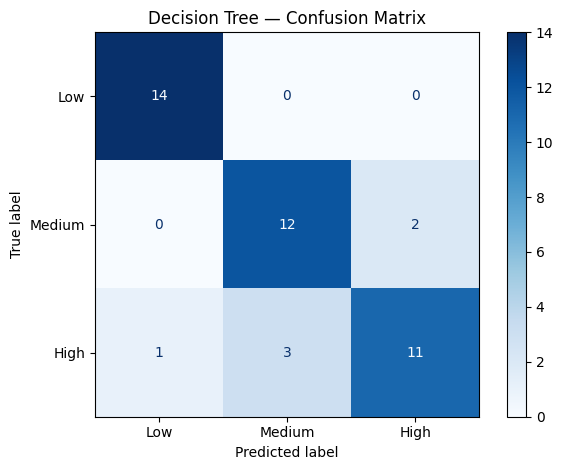

In [32]:
ConfusionMatrixDisplay.from_predictions(
    y_clf_test, dt_clf_pred,
    labels=["Low", "Medium", "High"],
    display_labels=["Low", "Medium", "High"],
    cmap="Blues"
)
plt.title("Decision Tree — Confusion Matrix")
plt.tight_layout()
plt.show()

## 10. Random Forest

**Simple idea:**  
Random Forest builds many Decision Trees on random subsets of data and features, then averages the results. This reduces overfitting and usually gives a more stable prediction.

In [33]:
# Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
rf_reg.fit(X_train, y_reg_train)
rf_reg_pred = rf_reg.predict(X_test)

print("Random Forest Regressor trained and predictions generated.")

Random Forest Regressor trained and predictions generated.


In [34]:
rf_mae  = mean_absolute_error(y_reg_test, rf_reg_pred)
rf_rmse = np.sqrt(mean_squared_error(y_reg_test, rf_reg_pred))
rf_r2   = r2_score(y_reg_test, rf_reg_pred)

print(f"MAE  : {rf_mae:>15,.0f} tons")
print(f"RMSE : {rf_rmse:>15,.0f} tons")
print(f"R²   : {rf_r2:.4f}")

MAE  :       1,231,147 tons
RMSE :       2,339,760 tons
R²   : 0.9520


In [35]:
# Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)
rf_clf.fit(X_train, y_clf_train)
rf_clf_pred = rf_clf.predict(X_test)

print("Random Forest Classifier trained and predictions generated.")

Random Forest Classifier trained and predictions generated.


In [36]:
rf_acc  = accuracy_score(y_clf_test, rf_clf_pred)
rf_prec = precision_score(y_clf_test, rf_clf_pred, average="weighted", zero_division=0)
rf_rec  = recall_score(y_clf_test, rf_clf_pred, average="weighted", zero_division=0)
rf_f1   = f1_score(y_clf_test, rf_clf_pred, average="weighted", zero_division=0)

print(f"Accuracy  : {rf_acc:.4f}")
print(f"Precision : {rf_prec:.4f}")
print(f"Recall    : {rf_rec:.4f}")
print(f"F1-Score  : {rf_f1:.4f}")

Accuracy  : 0.8605
Precision : 0.8778
Recall    : 0.8605
F1-Score  : 0.8585


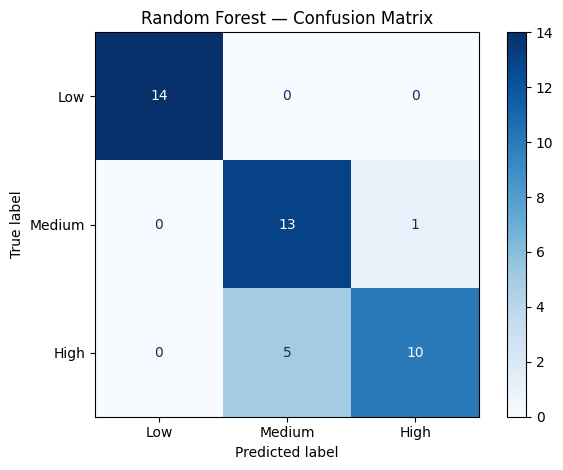

In [37]:
ConfusionMatrixDisplay.from_predictions(
    y_clf_test, rf_clf_pred,
    labels=["Low", "Medium", "High"],
    display_labels=["Low", "Medium", "High"],
    cmap="Blues"
)
plt.title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

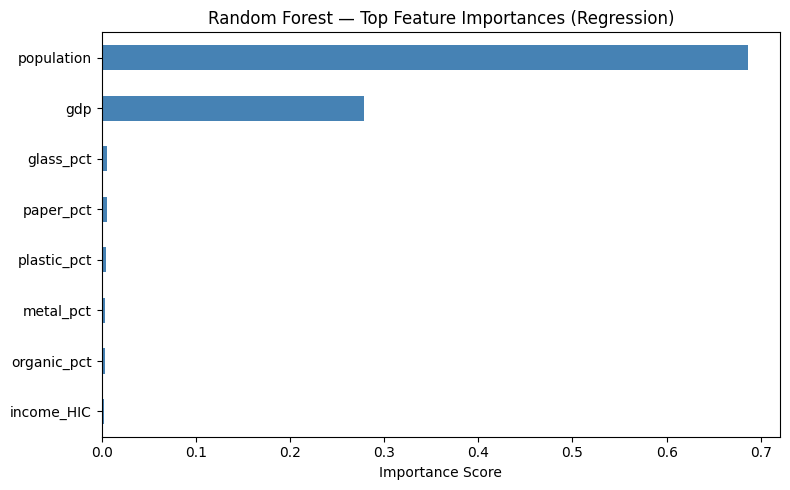

Top feature: population


In [38]:
rf_importances = pd.Series(rf_reg.feature_importances_, index=all_feature_names).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
rf_importances.tail(8).plot(kind="barh", color="steelblue")
plt.title("Random Forest — Top Feature Importances (Regression)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("Top feature:", rf_importances.idxmax())

## 11. Logistic Regression

**Simple idea:**  
Logistic Regression estimates the probability of an observation belonging to each class (Low / Medium / High) and assigns it to the most likely class.

In [39]:
log_clf = LogisticRegression(max_iter=1000, random_state=42)
log_clf.fit(X_train, y_clf_train)
log_clf_pred = log_clf.predict(X_test)

print("Logistic Regression trained and predictions generated.")

Logistic Regression trained and predictions generated.


In [40]:
log_acc  = accuracy_score(y_clf_test, log_clf_pred)
log_prec = precision_score(y_clf_test, log_clf_pred, average="weighted", zero_division=0)
log_rec  = recall_score(y_clf_test, log_clf_pred, average="weighted", zero_division=0)
log_f1   = f1_score(y_clf_test, log_clf_pred, average="weighted", zero_division=0)

print(f"Accuracy  : {log_acc:.4f}")
print(f"Precision : {log_prec:.4f}")
print(f"Recall    : {log_rec:.4f}")
print(f"F1-Score  : {log_f1:.4f}")

Accuracy  : 0.6047
Precision : 0.6585
Recall    : 0.6047
F1-Score  : 0.6049


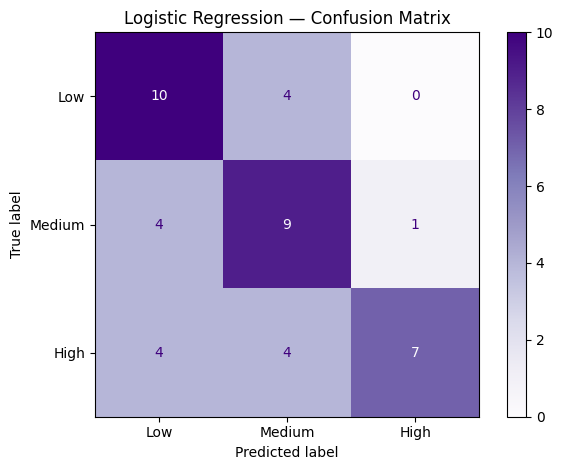

In [41]:
ConfusionMatrixDisplay.from_predictions(
    y_clf_test, log_clf_pred,
    labels=["Low", "Medium", "High"],
    display_labels=["Low", "Medium", "High"],
    cmap="Purples"
)
plt.title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

## 12. Naive Bayes

**Simple idea:**  
Naive Bayes uses probabilities (Bayes' theorem) to decide which class is most likely for a given observation. It assumes features are independent of each other.

In [42]:
nb_clf = GaussianNB()
nb_clf.fit(X_train, y_clf_train)
nb_clf_pred = nb_clf.predict(X_test)

print("Naive Bayes trained and predictions generated.")

Naive Bayes trained and predictions generated.


In [43]:
nb_acc  = accuracy_score(y_clf_test, nb_clf_pred)
nb_prec = precision_score(y_clf_test, nb_clf_pred, average="weighted", zero_division=0)
nb_rec  = recall_score(y_clf_test, nb_clf_pred, average="weighted", zero_division=0)
nb_f1   = f1_score(y_clf_test, nb_clf_pred, average="weighted", zero_division=0)

print(f"Accuracy  : {nb_acc:.4f}")
print(f"Precision : {nb_prec:.4f}")
print(f"Recall    : {nb_rec:.4f}")
print(f"F1-Score  : {nb_f1:.4f}")

Accuracy  : 0.5116
Precision : 0.8047
Recall    : 0.5116
F1-Score  : 0.4776


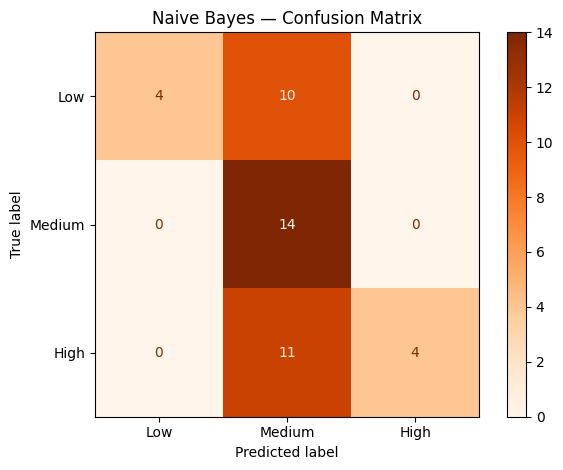

In [44]:
ConfusionMatrixDisplay.from_predictions(
    y_clf_test, nb_clf_pred,
    labels=["Low", "Medium", "High"],
    display_labels=["Low", "Medium", "High"],
    cmap="Oranges"
)
plt.title("Naive Bayes — Confusion Matrix")
plt.tight_layout()
plt.show()

## 13. Hierarchical Clustering

**Simple idea:**  
Hierarchical Clustering groups observations that are similar to each other **without** using any target label. It is an unsupervised method. We use it to discover natural groupings of countries based on waste-generation features.

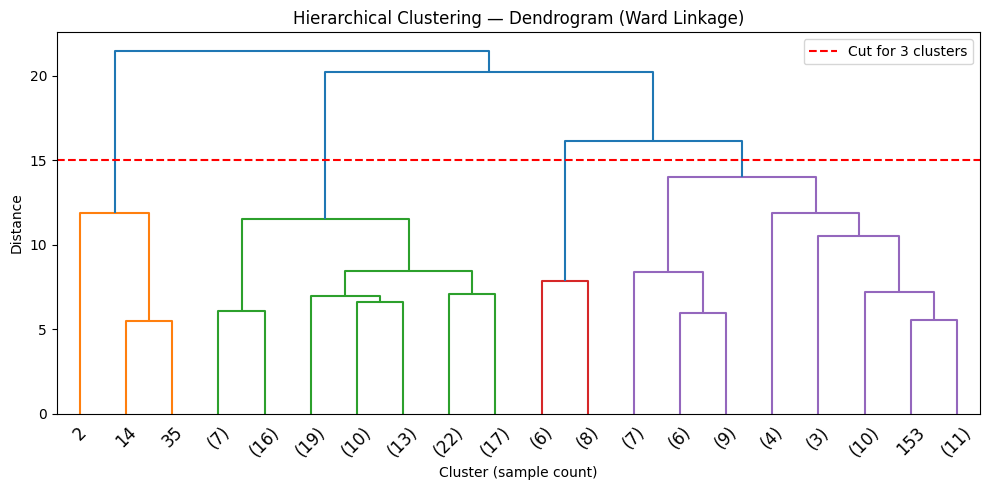

The red dashed line shows where we cut the dendrogram to get 3 clusters.


In [45]:
# Compute Ward linkage matrix on the preprocessed training data
linkage_matrix = linkage(X_train, method="ward")

plt.figure(figsize=(10, 5))
dendrogram(linkage_matrix, truncate_mode="lastp", p=20, leaf_rotation=45)
plt.title("Hierarchical Clustering — Dendrogram (Ward Linkage)")
plt.xlabel("Cluster (sample count)")
plt.ylabel("Distance")
plt.axhline(y=15, color="red", linestyle="--", label="Cut for 3 clusters")
plt.legend()
plt.tight_layout()
plt.show()

print("The red dashed line shows where we cut the dendrogram to get 3 clusters.")

In [46]:
# Fit Agglomerative Clustering with 3 clusters
agg = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="ward")
cluster_labels = agg.fit_predict(X_train)

print("Cluster distribution in training data:")
unique, counts = np.unique(cluster_labels, return_counts=True)
for c, n in zip(unique, counts):
    print(f"  Cluster {c}: {n} countries")

Cluster distribution in training data:
  Cluster 0: 65 countries
  Cluster 1: 3 countries
  Cluster 2: 104 countries


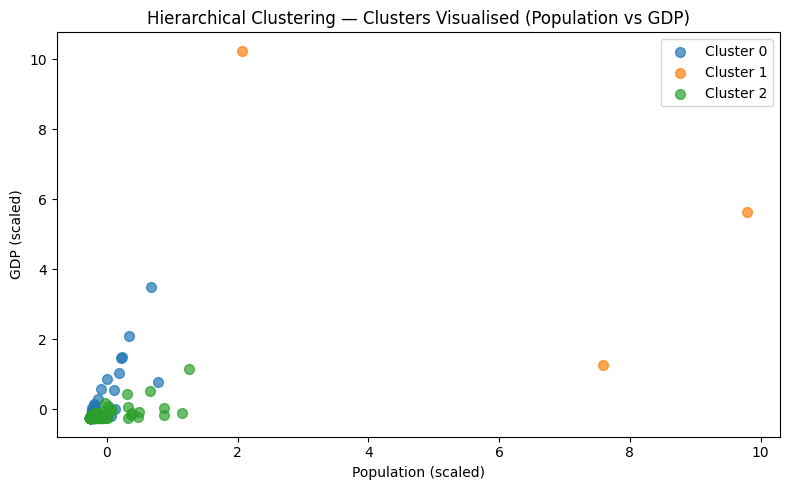

Insight: Clusters broadly correspond to developing, middle-income, and high-income economies.


In [47]:
# Visualise clusters using the two most important features (population and gdp)
X_train_df = pd.DataFrame(
    X_train[:, :len(num_features)],
    columns=num_features
)
X_train_df["cluster"] = cluster_labels

plt.figure(figsize=(8, 5))
for c in sorted(X_train_df["cluster"].unique()):
    sub = X_train_df[X_train_df["cluster"] == c]
    plt.scatter(sub["population"], sub["gdp"],
                label=f"Cluster {c}", alpha=0.7, s=50)

plt.xlabel("Population (scaled)")
plt.ylabel("GDP (scaled)")
plt.title("Hierarchical Clustering — Clusters Visualised (Population vs GDP)")
plt.legend()
plt.tight_layout()
plt.show()

print("Insight: Clusters broadly correspond to developing, middle-income, and high-income economies.")

**Note:** Clustering is an exploratory method. The clusters represent natural groupings found in the data, not predictions of waste tier. We do not evaluate clustering using Accuracy or R² — those metrics apply only to supervised models.

## 14. Model Comparison

### Regression Comparison (MAE, RMSE, R²)

These four models all perform the same task: predicting the continuous `waste_tons` value.

In [48]:
reg_comparison = pd.DataFrame({
    "Model": ["Linear Regression", "KNN Regressor", "Decision Tree", "Random Forest"],
    "MAE": [lr_mae, knn_mae, dt_mae, rf_mae],
    "RMSE": [lr_rmse, knn_rmse, dt_rmse, rf_rmse],
    "R² Score": [lr_r2, knn_r2, dt_r2, rf_r2]
})

reg_comparison = reg_comparison.sort_values("R² Score", ascending=False).reset_index(drop=True)
display(reg_comparison.style.format({"MAE": "{:,.0f}", "RMSE": "{:,.0f}", "R² Score": "{:.4f}"}))

,Model,MAE,RMSE,R² Score
0,Random Forest,"1,231,147","2,339,760",0.9520
1,Decision Tree,"1,577,749","3,348,949",0.9017
2,Linear Regression,"2,616,082","5,695,911",0.7158
3,KNN Regressor,"3,684,248","7,712,632",0.4789


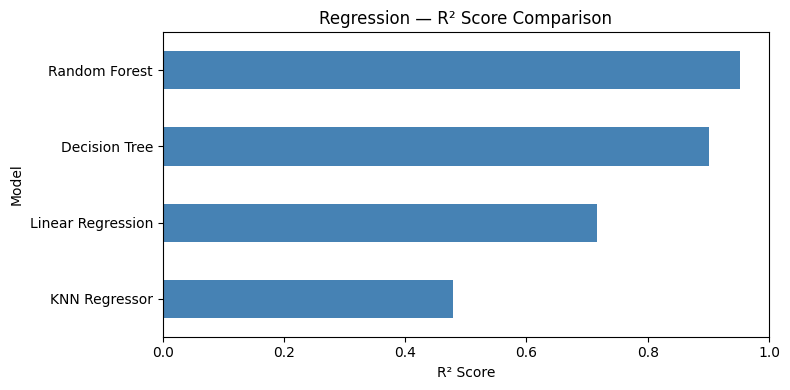

In [49]:
reg_comparison.set_index("Model")["R² Score"].sort_values().plot(
    kind="barh", figsize=(8, 4), color="steelblue"
)
plt.title("Regression — R² Score Comparison")
plt.xlabel("R² Score")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

### Classification Comparison (Accuracy, Precision, Recall, F1-Score)

These five models all perform the same task: predicting the `waste_tier` class (Low / Medium / High).

In [50]:
clf_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree", "Random Forest", "Naive Bayes"],
    "Accuracy" : [log_acc,  knn_acc,  dt_acc,  rf_acc,  nb_acc],
    "Precision": [log_prec, knn_prec, dt_prec, rf_prec, nb_prec],
    "Recall"   : [log_rec,  knn_rec,  dt_rec,  rf_rec,  nb_rec],
    "F1-Score" : [log_f1,   knn_f1,   dt_f1,   rf_f1,   nb_f1],
})

clf_comparison = clf_comparison.sort_values("F1-Score", ascending=False).reset_index(drop=True)
display(clf_comparison.style.format({
    "Accuracy": "{:.4f}", "Precision": "{:.4f}", "Recall": "{:.4f}", "F1-Score": "{:.4f}"
}))

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.8605,0.8778,0.8605,0.8585
1,Decision Tree,0.8605,0.8595,0.8605,0.8579
2,Logistic Regression,0.6047,0.6585,0.6047,0.6049
3,KNN,0.5581,0.5517,0.5581,0.5537
4,Naive Bayes,0.5116,0.8047,0.5116,0.4776


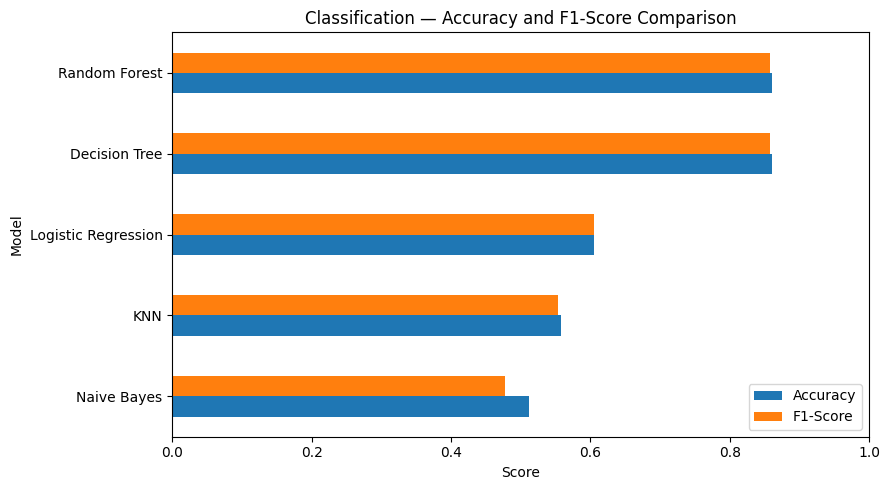

In [51]:
clf_comparison.set_index("Model")[["Accuracy", "F1-Score"]].sort_values("F1-Score").plot(
    kind="barh", figsize=(9, 5)
)
plt.title("Classification — Accuracy and F1-Score Comparison")
plt.xlabel("Score")
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

### Hierarchical Clustering — Result

Hierarchical Clustering is an **unsupervised** method and does not produce accuracy/R² scores.  
It discovered **3 natural country groupings** based on waste-related features without using any label:

| Cluster | Typical Profile |
|---------|----------------|
| 0 | Small developing nations — low GDP, high organic waste |
| 1 | Mid-sized economies — moderate waste volumes |
| 2 | Large or high-income economies — high GDP, high total waste |


## 15. Evaluation

In [52]:
# Identify best regression model
best_reg_idx = reg_comparison["R² Score"].idxmax()
best_reg_name = reg_comparison.loc[best_reg_idx, "Model"]
best_reg_r2   = reg_comparison.loc[best_reg_idx, "R² Score"]

# Identify best classification model
best_clf_idx = clf_comparison["F1-Score"].idxmax()
best_clf_name = clf_comparison.loc[best_clf_idx, "Model"]
best_clf_f1   = clf_comparison.loc[best_clf_idx, "F1-Score"]

print(f"Best Regression model   : {best_reg_name}  (R² = {best_reg_r2:.4f})")
print(f"Best Classification model: {best_clf_name}  (F1 = {best_clf_f1:.4f})")

Best Regression model   : Random Forest  (R² = 0.9520)
Best Classification model: Random Forest  (F1 = 0.8585)


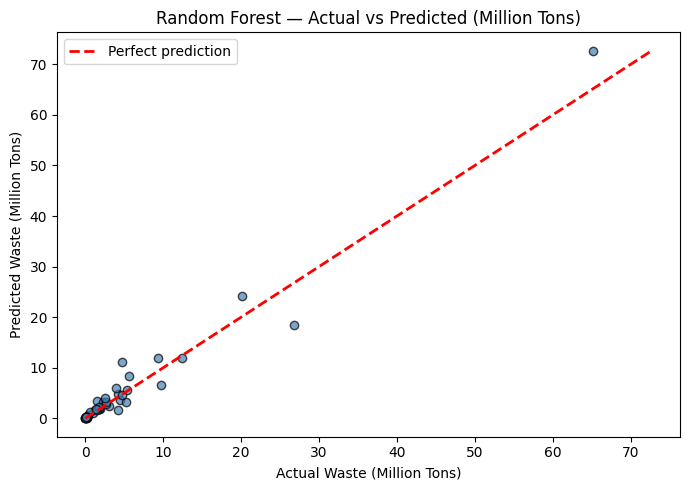

In [53]:
# Actual vs Predicted — best regression model
model_preds = {
    "Linear Regression": lr_pred,
    "KNN Regressor"    : knn_reg_pred,
    "Decision Tree"    : dt_reg_pred,
    "Random Forest"    : rf_reg_pred
}
best_reg_pred = model_preds[best_reg_name]

plt.figure(figsize=(7, 5))
plt.scatter(y_reg_test / 1e6, best_reg_pred / 1e6, color="steelblue", edgecolors="k", alpha=0.7)
max_val = max(y_reg_test.max(), best_reg_pred.max()) / 1e6
plt.plot([0, max_val], [0, max_val], "r--", lw=2, label="Perfect prediction")
plt.title(f"{best_reg_name} — Actual vs Predicted (Million Tons)")
plt.xlabel("Actual Waste (Million Tons)")
plt.ylabel("Predicted Waste (Million Tons)")
plt.legend()
plt.tight_layout()
plt.show()

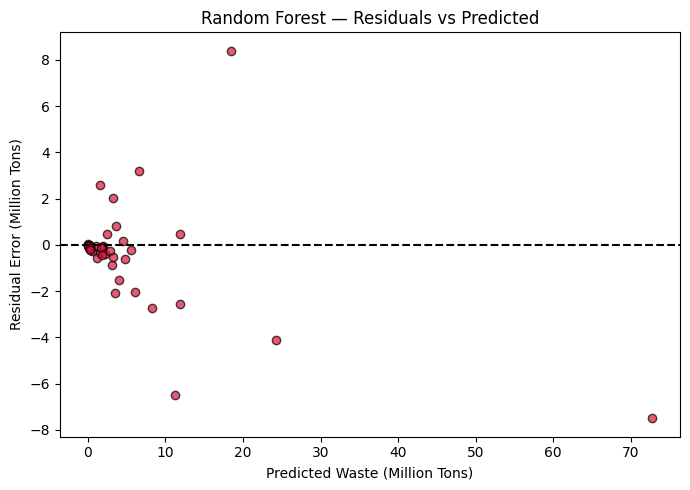

Residual mean (should be near 0): -0.3825


In [54]:
# Residual plot
residuals = (y_reg_test - best_reg_pred) / 1e6

plt.figure(figsize=(7, 5))
plt.scatter(best_reg_pred / 1e6, residuals, color="crimson", edgecolors="k", alpha=0.7)
plt.axhline(0, color="black", linestyle="--")
plt.title(f"{best_reg_name} — Residuals vs Predicted")
plt.xlabel("Predicted Waste (Million Tons)")
plt.ylabel("Residual Error (Million Tons)")
plt.tight_layout()
plt.show()

print("Residual mean (should be near 0):", residuals.mean().round(4))

### Limitations

1. **Cross-sectional data:** The dataset is a single snapshot.    It cannot capture year-on-year changes due to policy or economic shifts.
2. **High missingness in composition columns:** About 19–21 % of values are missing    in organic, paper, plastic, glass and metal columns.
3. **Informal waste sector:** Recyclables collected by informal waste pickers before    municipal collection are partially uncaptured.
4. **Small dataset:** 215 usable rows is a small sample for ML;    models may not generalise perfectly to unseen countries.

## 16. Final Prediction — Demonstration

We demonstrate the trained models on a hypothetical new country with known features.

In [55]:
# Example: a hypothetical middle-income country
new_country_num = pd.DataFrame([[
    5.0e10,    # gdp          — USD 50 billion
    2.0e7,     # population   — 20 million
    48.0,      # organic_pct  — 48 %
    4.0,       # glass_pct    — 4 %
    3.5,       # metal_pct    — 3.5 %
    15.0,      # other_pct    — 15 %
    12.0,      # paper_pct    — 12 %
    10.0       # plastic_pct  — 10 %
]], columns=num_features)

new_country_cat = pd.DataFrame([["UMC", "ECS"]], columns=cat_features)

# Apply the same preprocessing
new_num_prep = scaler.transform(imputer.transform(new_country_num))
new_cat_prep = encoder.transform(new_country_cat)
new_X = np.hstack([new_num_prep, new_cat_prep])

print("New country feature vector prepared.")

New country feature vector prepared.


In [56]:
# Regression prediction
reg_model_objects = {
    "Linear Regression": lr_model,
    "KNN Regressor"    : knn_reg,
    "Decision Tree"    : dt_reg,
    "Random Forest"    : rf_reg
}
best_reg_model = reg_model_objects[best_reg_name]
reg_result = best_reg_model.predict(new_X)[0]
print(f"Predicted annual waste generation ({best_reg_name}):")
print(f"  {reg_result:,.0f} tons/year  ({reg_result/1e6:.2f} million tons/year)")

# Classification prediction
clf_model_objects = {
    "Logistic Regression": log_clf,
    "KNN"                : knn_clf,
    "Decision Tree"      : dt_clf,
    "Random Forest"      : rf_clf,
    "Naive Bayes"        : nb_clf
}
best_clf_model = clf_model_objects[best_clf_name]
clf_result = best_clf_model.predict(new_X)[0]
print(f"\nPredicted waste tier ({best_clf_name}): {clf_result}")

Predicted annual waste generation (Random Forest):
  3,670,794 tons/year  (3.67 million tons/year)

Predicted waste tier (Random Forest): Medium


## 17. Conclusion

In [57]:
print('=' * 60)
print('Waste Generation Analysis -- Project Conclusion')
print('=' * 60)
print()
print('Problem addressed:')
print('  A municipal organization wants to investigate factors')
print('  associated with changes in waste generation (Case Study 73).')
print()
print('Dataset used:')
print('  World Bank What A Waste Global Dataset')
print('  (Kaggle: mannmann2/what-a-waste-global-dataset)')
print('  217 countries, 51 original columns.')
print()
print('Key findings from EDA:')
print('  - Population and GDP are the two strongest predictors')
print('    of annual municipal solid waste generation.')
print('  - Low-income countries produce >60% organic/food waste.')
print('  - High-income countries produce more paper, plastic')
print('    and glass recyclables.')
print()
print(f'Best Regression model     : {best_reg_name}  (R2 = {best_reg_r2:.4f})')
print(f'Best Classification model : {best_clf_name}  (F1 = {best_clf_f1:.4f})')
print()
print('Clustering:')
print('  Hierarchical Clustering (Ward linkage, 3 clusters)')
print('  discovered natural groupings of countries by waste')
print('  profile without using any target label.')
print()
print('How this helps the municipal organization:')
print('  - The regression model can forecast waste volumes for')
print('    budget and infrastructure planning.')
print('  - The classification model identifies Low/Medium/High regions.')
print('  - Clustering reveals structural similarities for shared strategies.')
print()
print('Limitations:')
print('  - Cross-sectional snapshot data only.')
print('  - High missingness in composition columns (~20%).')
print('  - Small sample size (215 countries).')
print()
print('Project completed successfully.')

Waste Generation Analysis -- Project Conclusion

Problem addressed:
  A municipal organization wants to investigate factors
  associated with changes in waste generation (Case Study 73).

Dataset used:
  World Bank What A Waste Global Dataset
  (Kaggle: mannmann2/what-a-waste-global-dataset)
  217 countries, 51 original columns.

Key findings from EDA:
  - Population and GDP are the two strongest predictors
    of annual municipal solid waste generation.
  - Low-income countries produce >60% organic/food waste.
  - High-income countries produce more paper, plastic
    and glass recyclables.

Best Regression model     : Random Forest  (R2 = 0.9520)
Best Classification model : Random Forest  (F1 = 0.8585)

Clustering:
  Hierarchical Clustering (Ward linkage, 3 clusters)
  discovered natural groupings of countries by waste
  profile without using any target label.

How this helps the municipal organization:
  - The regression model can forecast waste volumes for
    budget and infrastruct

*Project completed — Case Study No. 73 requirements satisfied.*